<a href="https://colab.research.google.com/github/kxrrym03/Data-Center-AI-Water-Electricity-Usage/blob/main/Water_Electricity_Usage_in_Data_Centers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_center_hybrid.csv to data_center_hybrid.csv


In [ ]:
df = pd.read_csv('data_center_hybrid.csv')
df.shape

(126770, 14)

In [ ]:
df.head()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


In [ ]:
df.tail()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
126765,2021,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Unknown,Türkiye,Enterprise/Standard,14.51,1.495,Evaporative,2.305,381.65,155454.82,High
126766,2022,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Unknown,Türkiye,Enterprise/Standard,14.77,1.485,Evaporative,2.281,378.59,153627.09,High
126767,2023,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Unknown,Türkiye,Enterprise/Standard,15.04,1.473,Evaporative,2.245,319.36,128626.89,High
126768,2024,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Unknown,Türkiye,Enterprise/Standard,15.31,1.450,Evaporative,2.231,394.69,160407.53,High
126769,2025,DC-31D8B15E,ICS_DataCenter_216,ICS BİLİŞİM TEKNOLOJİLERİ DANIŞMANLIK HİZMETLE...,Unknown,Türkiye,Enterprise/Standard,15.58,1.431,Evaporative,2.217,463.45,189650.23,High


In [ ]:
df.isnull().sum()

,0
Year,0
Facility_ID,0
Facility_Name,0
Owner_Company,0
City,0
Country,0
Facility_Type,0
Estimated_Capacity_MW,0
PUE,0
Cooling_System_Type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000,1.267700e+05
mean,2022.000000,23.075117,1.637746,0.820596,605.222368,1.312182e+05
std,2.000008,45.847195,0.190833,0.925481,1040.061940,3.979629e+05
min,2019.000000,1.000000,1.057000,0.001000,22.190000,2.240100e+02
25%,2020.000000,5.450000,1.518000,0.139000,167.432500,4.840538e+03
50%,2022.000000,9.870000,1.643000,0.232000,302.750000,1.218130e+04
75%,2024.000000,14.180000,1.787000,1.654000,451.370000,7.573068e+04
max,2025.000000,562.890000,2.000000,3.000000,14812.660000,7.585092e+06


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126770 entries, 0 to 126769
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Year                           126770 non-null  int64  
 1   Facility_ID                    126770 non-null  object 
 2   Facility_Name                  126770 non-null  object 
 3   Owner_Company                  126770 non-null  object 
 4   City                           126770 non-null  object 
 5   Country                        126770 non-null  object 
 6   Facility_Type                  126770 non-null  object 
 7   Estimated_Capacity_MW          126770 non-null  float64
 8   PUE                            126770 non-null  float64
 9   Cooling_System_Type            126770 non-null  object 
 10  WUE_L_per_kWh                  126770 non-null  float64
 11  Daily_Electricity_Usage_MWh    126770 non-null  float64
 12  Daily_Water_Usage_Gallons     

In [ ]:
df.dtypes

,0
Year,int64
Facility_ID,object
Facility_Name,object
Owner_Company,object
City,object
Country,object
Facility_Type,object
Estimated_Capacity_MW,float64
PUE,float64
Cooling_System_Type,object


### Data Visualization

### Distribution of Numerical Features

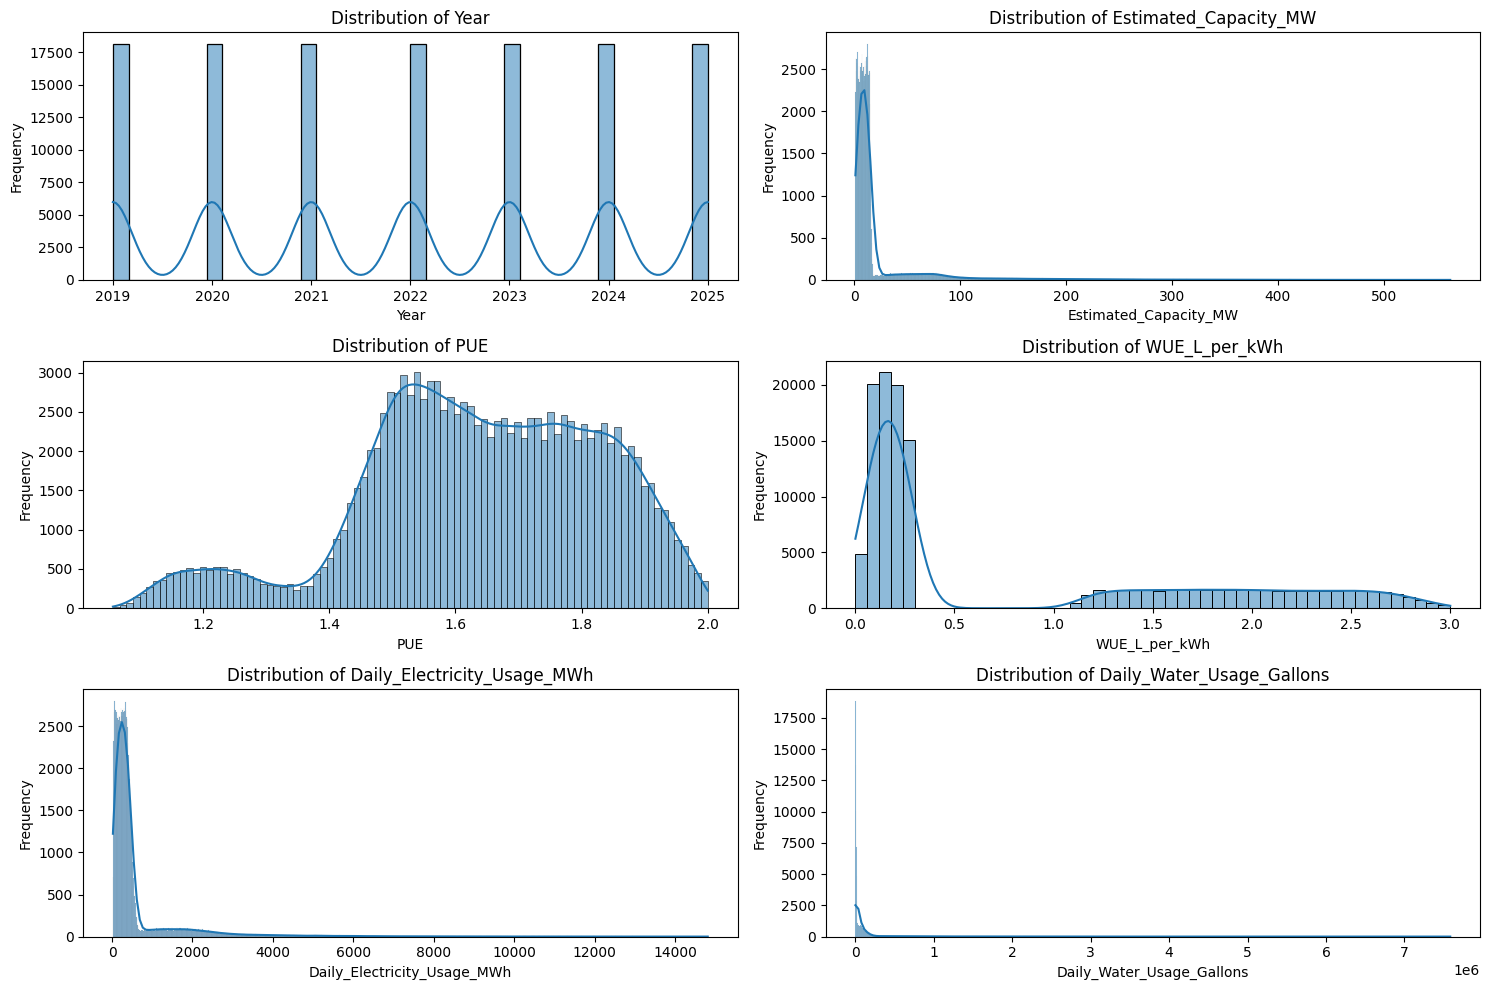

In [ ]:
numerical_cols = ['Year', 'Estimated_Capacity_MW', 'PUE', 'WUE_L_per_kWh', 'Daily_Electricity_Usage_MWh', 'Daily_Water_Usage_Gallons']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Distribution of Categorical Features

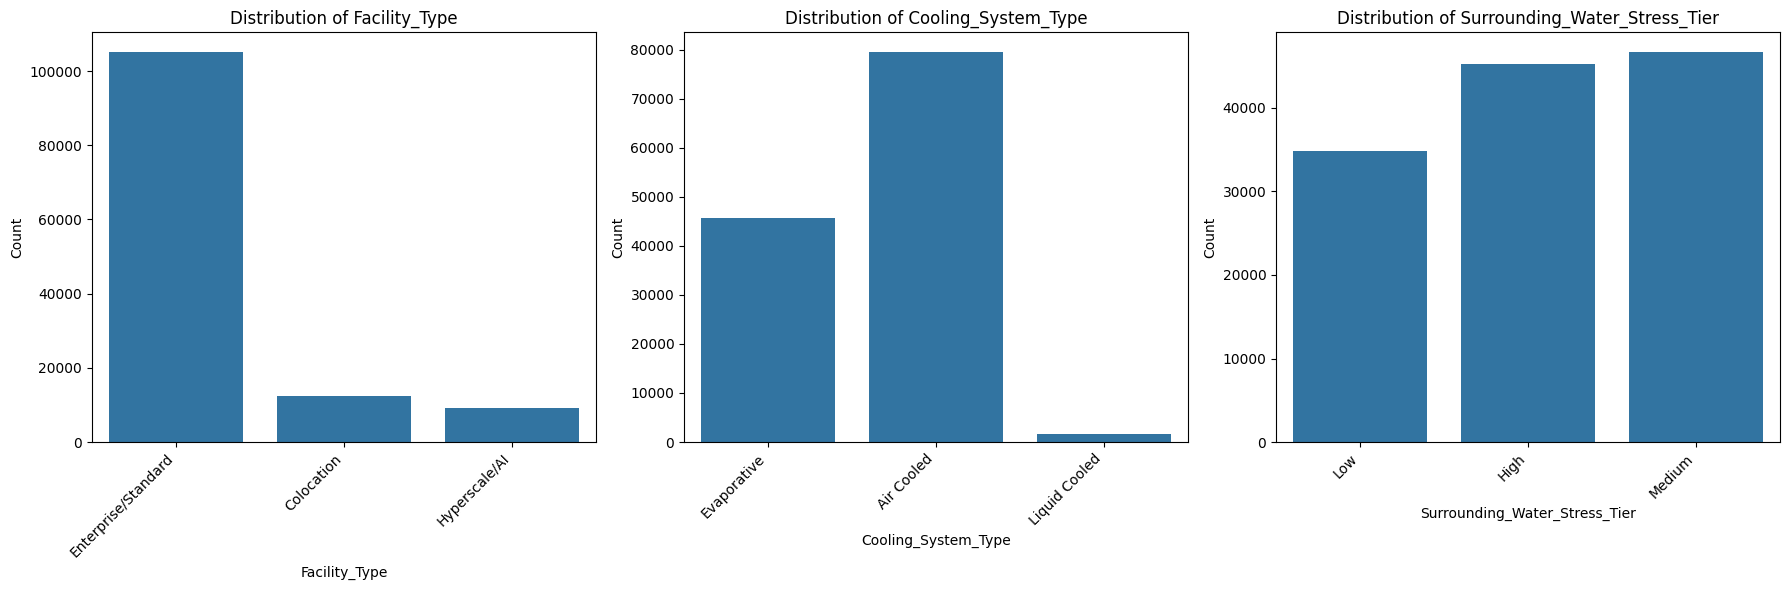

In [ ]:
categorical_cols = ['Facility_Type', 'Cooling_System_Type', 'Surrounding_Water_Stress_Tier']

plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Correlation Matrix of Numerical Features

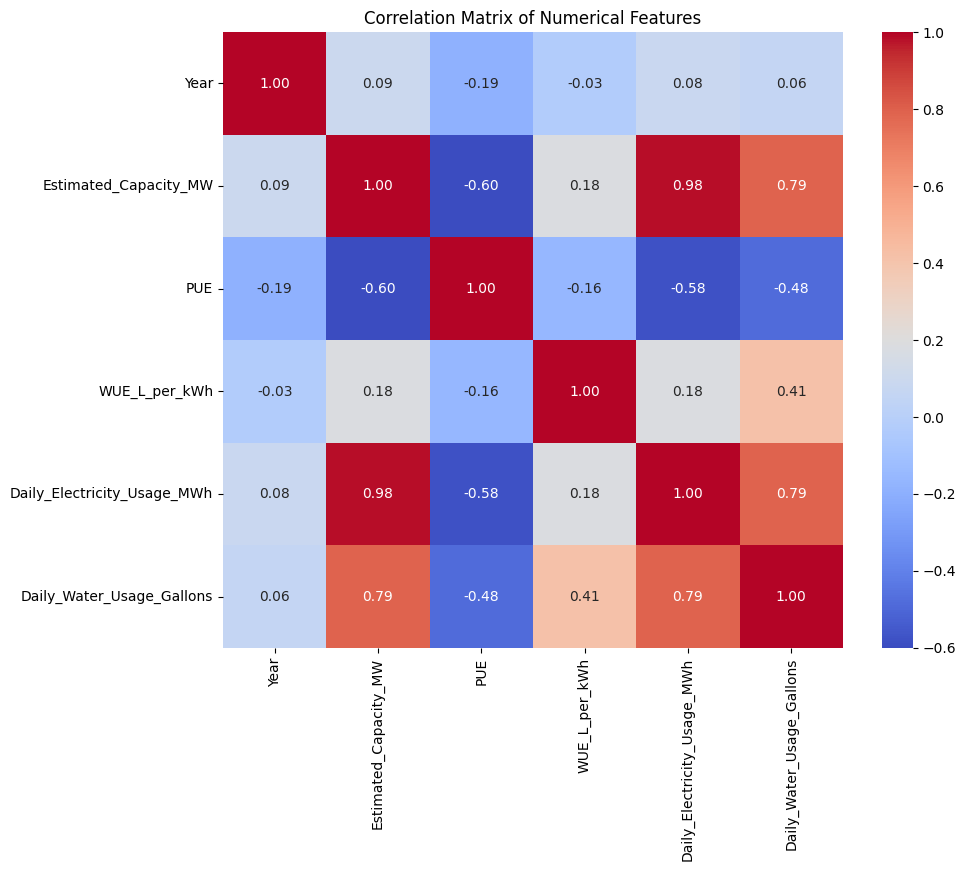

In [ ]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Relationship between Categorical and Numerical Features

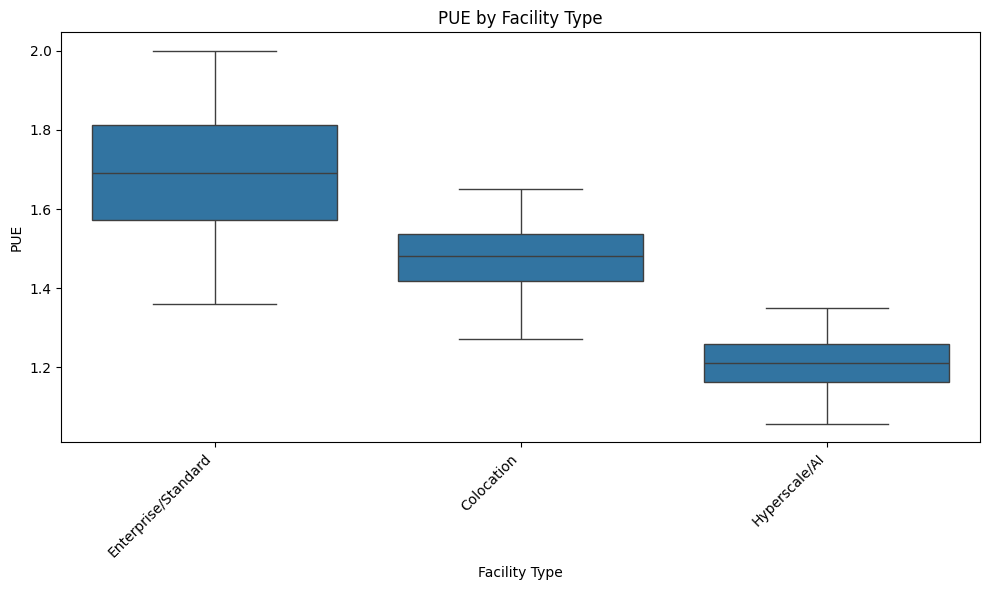

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Facility_Type', y='PUE')
plt.title('PUE by Facility Type')
plt.xlabel('Facility Type')
plt.ylabel('PUE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

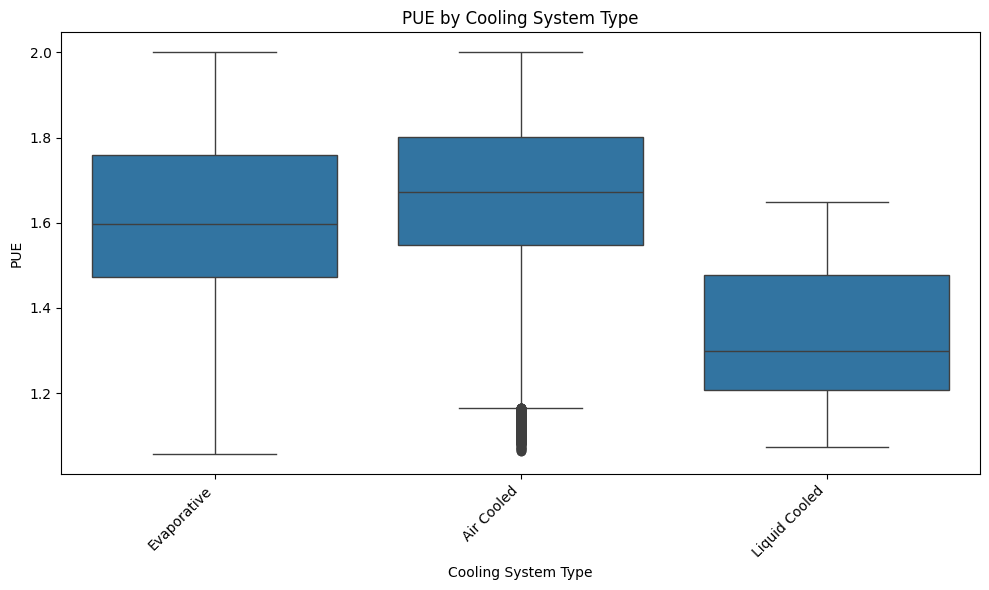

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Cooling_System_Type', y='PUE')
plt.title('PUE by Cooling System Type')
plt.xlabel('Cooling System Type')
plt.ylabel('PUE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

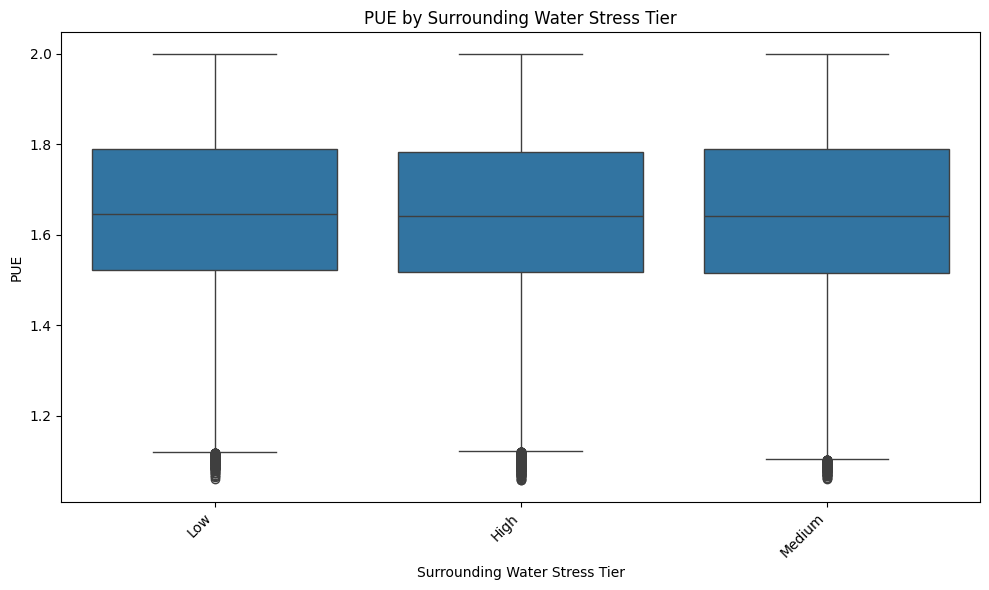

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Surrounding_Water_Stress_Tier', y='PUE')
plt.title('PUE by Surrounding Water Stress Tier')
plt.xlabel('Surrounding Water Stress Tier')
plt.ylabel('PUE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
mean_pue_by_owner = df.groupby('Owner_Company')['PUE'].mean().sort_values(ascending=False)
display(mean_pue_by_owner.head())

,PUE
Owner_Company,
Business Sviaz Holding,1.960000
Linkbynet,1.957286
Paratus Africa,1.950714
Pomorskie Centrum Przetwarzania Danych Sp. z o.o.,1.948857
POP-MG,1.948714


### Top 10 Companies by Mean PUE

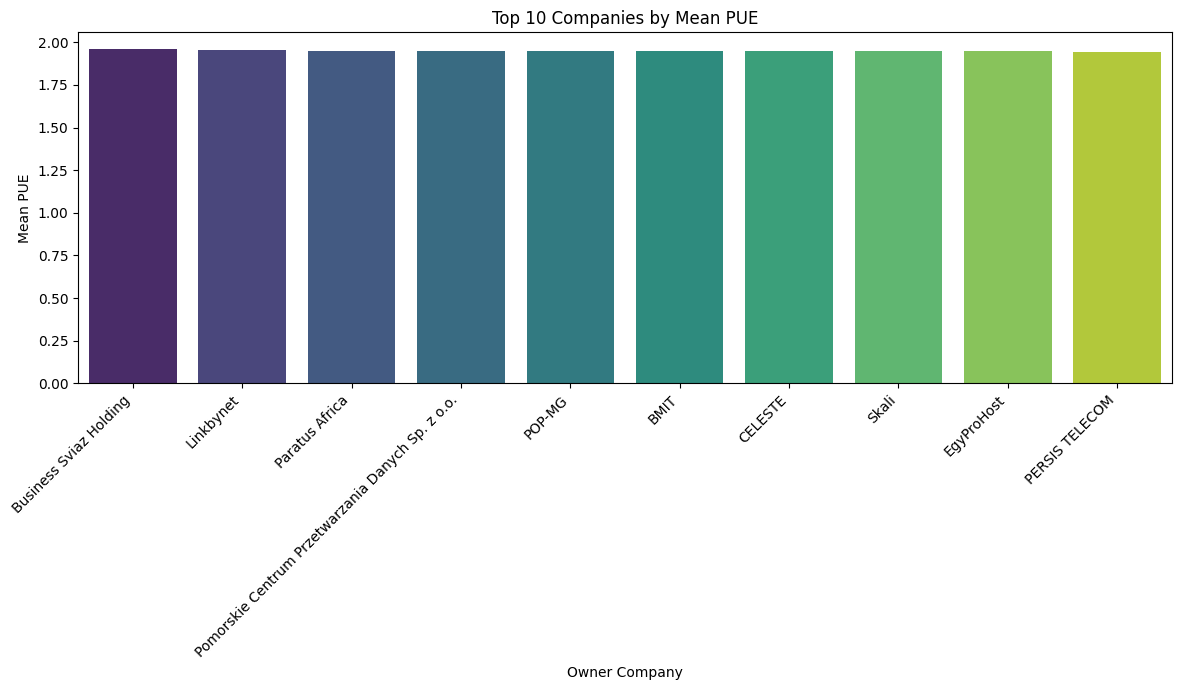

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=mean_pue_by_owner.head(10).index, y=mean_pue_by_owner.head(10).values, palette='viridis')
plt.title('Top 10 Companies by Mean PUE')
plt.xlabel('Owner Company')
plt.ylabel('Mean PUE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bottom 10 Companies by Mean PUE

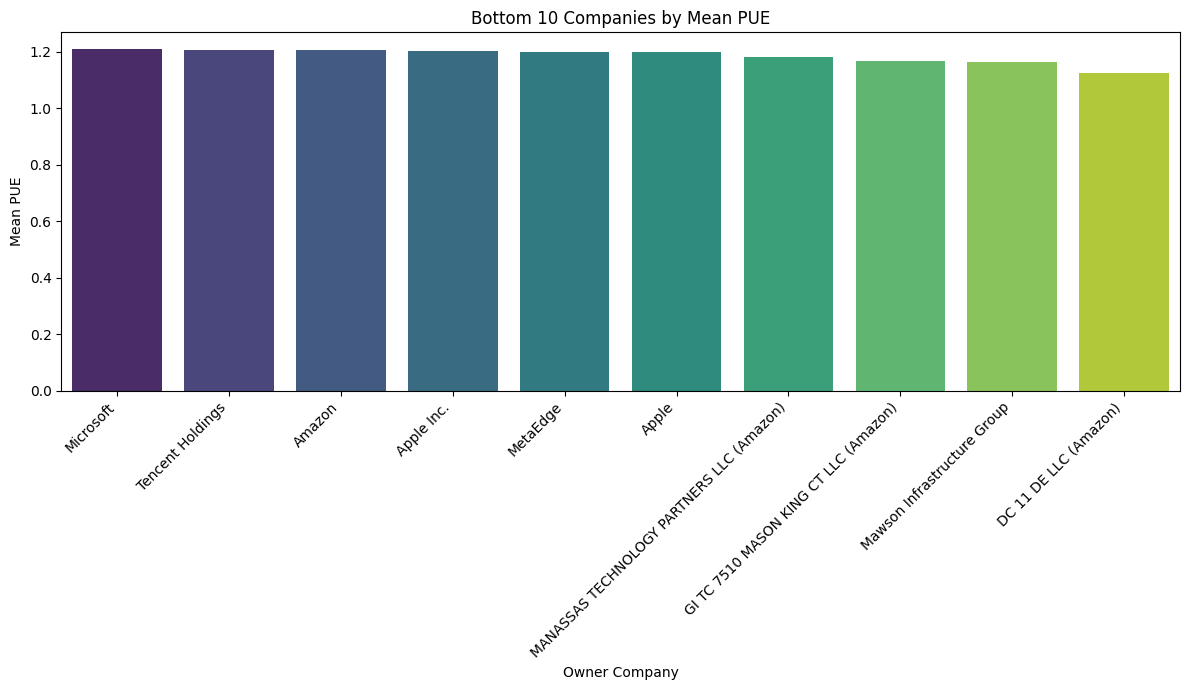

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=mean_pue_by_owner.tail(10).index, y=mean_pue_by_owner.tail(10).values, palette='viridis')
plt.title('Bottom 10 Companies by Mean PUE')
plt.xlabel('Owner Company')
plt.ylabel('Mean PUE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Machine Learning

### Feature Engineering

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define target and features
y = df['PUE']
X = df.drop(['PUE', 'Facility_ID', 'Facility_Name', 'Owner_Company', 'City', 'Country'], axis=1)

# Identify categorical and numerical columns for preprocessing
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply preprocessing to the features
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
onehot_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
processed_feature_names = list(numerical_features) + list(onehot_features)

X_processed_df = pd.DataFrame(X_processed, columns=processed_feature_names)

display(X_processed_df.head())

,Year,Estimated_Capacity_MW,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Facility_Type_Colocation,Facility_Type_Enterprise/Standard,Facility_Type_Hyperscale/AI,Cooling_System_Type_Air Cooled,Cooling_System_Type_Evaporative,Cooling_System_Type_Liquid Cooled,Surrounding_Water_Stress_Tier_High,Surrounding_Water_Stress_Tier_Low,Surrounding_Water_Stress_Tier_Medium
0,-1.5,-0.367202,0.713582,-0.405364,-0.238353,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-1.0,-0.364585,0.689810,-0.337368,-0.204504,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.5,-0.362185,0.680086,-0.325340,-0.196481,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,-0.359568,0.640106,-0.390442,-0.231228,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.5,-0.357169,0.614174,-0.364674,-0.218242,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (101416, 14)
X_test shape: (25354, 14)
y_train shape: (101416,)
y_test shape: (25354,)


### Model Selection and Training

### Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Linear Regression R-squared (R2): {r2_lr:.4f}")

Linear Regression Mean Squared Error (MSE): 0.0167
Linear Regression R-squared (R2): 0.5405


#### Plotting Predicted vs. Actual Values

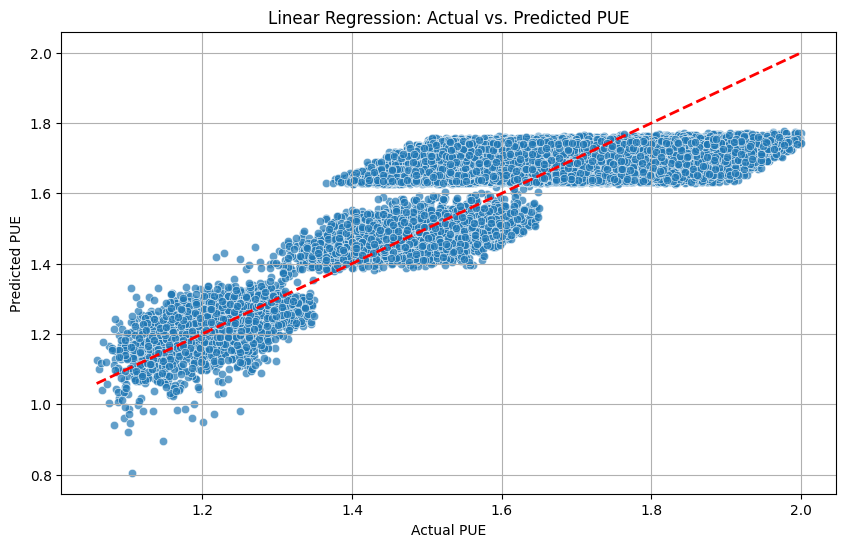

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual PUE')
plt.ylabel('Predicted PUE')
plt.title('Linear Regression: Actual vs. Predicted PUE')
plt.grid(True)
plt.show()

### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"Random Forest Regressor R-squared (R2): {r2_rf:.4f}")

Random Forest Regressor Mean Squared Error (MSE): 0.0052
Random Forest Regressor R-squared (R2): 0.8567


#### Feature Importance from Random Forest Model

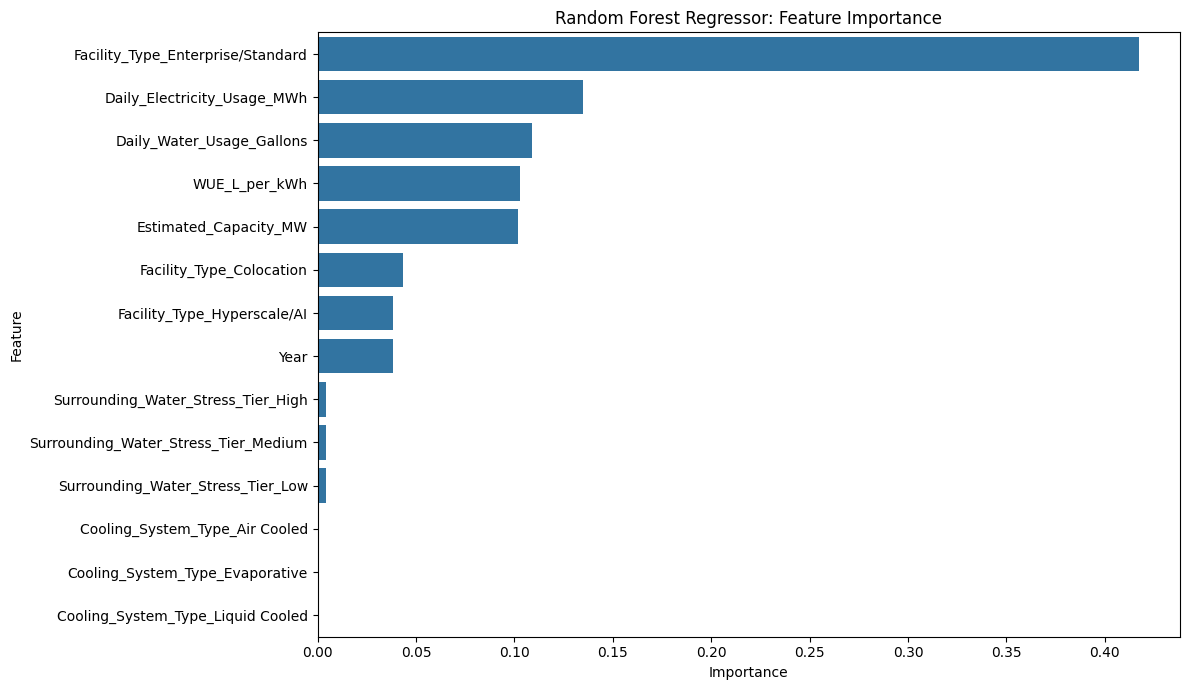

In [ ]:
# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Random Forest Regressor: Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Cross-Validation for Random Forest Model

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Define the number of folds for cross-validation
k_folds = 5

# Initialize KFold cross-validator
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Perform cross-validation on the Random Forest model
cv_scores_rf = cross_val_score(rf_model, X_processed_df, y, cv=kf, scoring='neg_mean_squared_error')

# Convert negative MSE scores to positive
cv_mse_rf = -cv_scores_rf

print(f"Random Forest Regressor Cross-Validation MSE Scores: {cv_mse_rf}")
print(f"Mean Cross-Validation MSE for Random Forest: {cv_mse_rf.mean():.4f}")
print(f"Standard Deviation of Cross-Validation MSE for Random Forest: {cv_mse_rf.std():.4f}")

Random Forest Regressor Cross-Validation MSE Scores: [0.00517256 0.00523466 0.00503636 0.00524867 0.00520284]
Mean Cross-Validation MSE for Random Forest: 0.0052
Standard Deviation of Cross-Validation MSE for Random Forest: 0.0001


### Plotting Predicted vs. Actual Values (Random Forest)

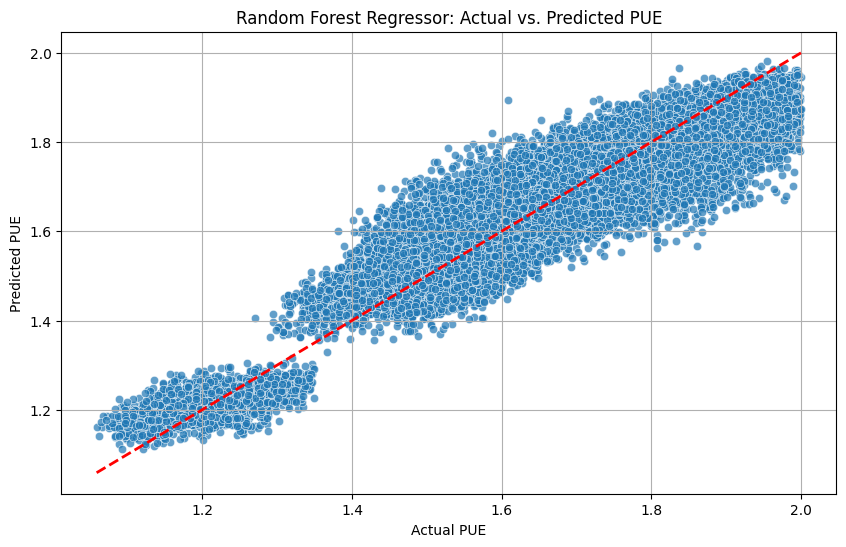

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual PUE')
plt.ylabel('Predicted PUE')
plt.title('Random Forest Regressor: Actual vs. Predicted PUE')
plt.grid(True)
plt.show()